In [1]:
import pandas as pd
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
from sysquant.estimators.vol import robust_vol_calc

data = csvFuturesSimData()


def calc_buy_and_hold_forecast(price):
    """
    : the trading rule function returns a series of forecast, not actual positions

    """

    return pd.Series(10, index=price.index)


Configuring sim logging


In [18]:
instrument_code = "SP500"
price = data.daily_prices(instrument_code)
buyandhold = calc_buy_and_hold_forecast(price)
from systems.accounts.account_forecast import pandl_for_instrument_forecast

account = pandl_for_instrument_forecast(forecast=buyandhold, price=price)
account.percent.stats()


[[('min', '-16.99'),
  ('max', '7.06'),
  ('median', '0.0455'),
  ('mean', '0.03599'),
  ('std', '1.062'),
  ('skew', '-1.02'),
  ('ann_mean', '9.214'),
  ('ann_std', '16.99'),
  ('sharpe', '0.5422'),
  ('sortino', '0.6905'),
  ('avg_drawdown', '-12.65'),
  ('time_in_drawdown', '0.9421'),
  ('calmar', '0.1362'),
  ('avg_return_to_drawdown', '0.7283'),
  ('avg_loss', '-0.8173'),
  ('avg_gain', '0.769'),
  ('gaintolossratio', '0.9408'),
  ('profitfactor', '1.099'),
  ('hitrate', '0.5389'),
  ('t_stat', '3.528'),
  ('p_value', '0.0004203')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

In [ ]:
account.pandl_calculator_with_costs.positions


index
1982-09-14         NaN
1982-09-15         NaN
1982-09-16         NaN
1982-09-17         NaN
1982-09-20         NaN
                ...   
2024-03-22    0.031329
2024-03-25    0.031551
2024-03-26    0.032205
2024-03-27    0.032918
2024-03-28    0.033037
Freq: B, Length: 10838, dtype: float64

In [3]:
import pandas as pd
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
from sysdata.config.configdata import Config
from systems.basesystem import System
from systems.forecasting import Rules
from systems.trading_rules import TradingRule
from systems.forecast_scale_cap import ForecastScaleCap
from systems.forecast_combine import ForecastCombine
from systems.positionsizing import PositionSizing
from systems.portfolio import Portfolios
from systems.accounts.accounts_stage import Account
from systems.rawdata import RawData

data = csvFuturesSimData()


def calc_buy_and_hold_forecast(price):
    return pd.Series(10, index=price.index)


buyandhold_rule = TradingRule(calc_buy_and_hold_forecast)

my_config = Config()
my_config.instruments = ["SP500"]
my_config.trading_rules = dict(buyandhold=buyandhold_rule)

# forecast scaling/capping — "1.0" scalar just passes your constant 10 straight through
my_config.forecast_scalars = dict(buyandhold=1.0)
my_config.forecast_cap = 20.0
my_config.use_forecast_scale_estimates = False

# combine (only one rule, so weight = 1)
my_config.forecast_weights = dict(buyandhold=1.0)
my_config.forecast_div_multiplier = 1.0
my_config.use_forecast_weight_estimates = False
my_config.use_forecast_div_mult_estimates = False

# portfolio (only one instrument, so weight = 1)
my_config.instrument_weights = dict(SP500=1.0)
my_config.instrument_div_multiplier = 1.0
my_config.use_instrument_weight_estimates = False
my_config.use_instrument_div_mult_estimates = False

# real capital/risk settings instead of the $100 arbitrary defaults
my_config.percentage_vol_target = 16.0
my_config.notional_trading_capital = 1000000
my_config.base_currency = "USD"

my_system = System(
    [
        Account(),
        Portfolios(),
        PositionSizing(),
        ForecastCombine(),
        ForecastScaleCap(),
        Rules(),
        RawData(),
    ],
    data,
    my_config,
)

my_system.accounts.portfolio().percent.stats()


2026-08-27 10:54:46 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-08-27 10:54:46 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-08-27 10:54:46 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-08-27 10:54:46 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-08-27 10:54:46 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-08-27 10:54:46 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'SP500'} Calculating pandl for instrument for SP500
2026-08-27 10:54:46 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SP500'} Calculating notional position for SP500
2026-08-27 10:54:46 INFO base_system {'stage': 'portfolio', 'instrument_code': 'SP500'} Calculating instrument weights
2026-08-27 10:54:46 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 

[[('min', '-22.61'),
  ('max', '6.309'),
  ('median', '0.045'),
  ('mean', '0.03517'),
  ('std', '1.095'),
  ('skew', '-1.377'),
  ('ann_mean', '9.003'),
  ('ann_std', '17.51'),
  ('sharpe', '0.5141'),
  ('sortino', '0.6404'),
  ('avg_drawdown', '-13.82'),
  ('time_in_drawdown', '0.9394'),
  ('calmar', '0.1329'),
  ('avg_return_to_drawdown', '0.6514'),
  ('avg_loss', '-0.8249'),
  ('avg_gain', '0.7809'),
  ('gaintolossratio', '0.9467'),
  ('profitfactor', '1.095'),
  ('hitrate', '0.5364'),
  ('t_stat', '3.345'),
  ('p_value', '0.0008256')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

2026-08-27 10:53:11 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-08-27 10:53:11 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-08-27 10:53:11 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-08-27 10:53:11 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-08-27 10:53:11 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-08-27 10:53:11 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'SP500'} Calculating pandl for instrument for SP500
2026-08-27 10:53:11 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SP500'} Calculating notional position for SP500
2026-08-27 10:53:11 INFO base_system {'stage': 'portfolio', 'instrument_code': 'SP500'} Calculating instrument weights
2026-08-27 10:53:11 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 

[[('min', '-18.57'),
  ('max', '6.724'),
  ('median', '0.04375'),
  ('mean', '0.0352'),
  ('std', '1.039'),
  ('skew', '-1.164'),
  ('ann_mean', '9.011'),
  ('ann_std', '16.63'),
  ('sharpe', '0.5419'),
  ('sortino', '0.6827'),
  ('avg_drawdown', '-12'),
  ('time_in_drawdown', '0.9387'),
  ('calmar', '0.1428'),
  ('avg_return_to_drawdown', '0.7511'),
  ('avg_loss', '-0.7832'),
  ('avg_gain', '0.7471'),
  ('gaintolossratio', '0.954'),
  ('profitfactor', '1.1'),
  ('hitrate', '0.5356'),
  ('t_stat', '3.526'),
  ('p_value', '0.0004236')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

In [19]:
import pandas as pd
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
from sysdata.config.configdata import Config
from systems.basesystem import System
from systems.forecasting import Rules
from systems.trading_rules import TradingRule
from systems.forecast_scale_cap import ForecastScaleCap
from systems.forecast_combine import ForecastCombine
from systems.positionsizing import PositionSizing
from systems.portfolio import Portfolios
from systems.accounts.accounts_stage import Account
from systems.rawdata import RawData

data = csvFuturesSimData()


def calc_buy_and_hold_forecast(price):
    return pd.Series(10, index=price.index)


my_rules = Rules(dict(buyandhold=calc_buy_and_hold_forecast))

my_config = Config()
my_config.instruments = ["SP500"]
# my_config.trading_rules = dict(buyandhold=buyandhold_rule)

# forecast scaling/capping — "1.0" scalar just passes your constant 10 straight through
my_config.forecast_scalars = dict(buyandhold=1.0)
my_config.forecast_cap = 20.0
my_config.use_forecast_scale_estimates = False

# combine (only one rule, so weight = 1)
my_config.forecast_weights = dict(buyandhold=1.0)
my_config.forecast_div_multiplier = 1.0
my_config.use_forecast_weight_estimates = False
my_config.use_forecast_div_mult_estimates = False

# portfolio (only one instrument, so weight = 1)
my_config.instrument_weights = dict(SP500=1.0)
my_config.instrument_div_multiplier = 1.0
my_config.use_instrument_weight_estimates = False
my_config.use_instrument_div_mult_estimates = False

# real capital/risk settings instead of the $100 arbitrary defaults
my_config.percentage_vol_target = 16.0
my_config.notional_trading_capital = 1000000
my_config.base_currency = "USD"

my_config.volatility_calculation = dict(
    func="sysquant.estimators.vol.robust_vol_calc",
    name_returns_attr_in_rawdata="daily_returns",
    multiplier_to_get_daily_vol=1.0,
)


my_system = System(
    [
        Account(),
        Portfolios(),
        PositionSizing(),
        ForecastCombine(),
        ForecastScaleCap(),
        RawData(),
        my_rules,
    ],
    data,
    my_config,
)


In [20]:
my_system.accounts.portfolio().percent.stats()


2026-08-21 14:01:41 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-08-21 14:01:41 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-08-21 14:01:41 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-08-21 14:01:41 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-08-21 14:01:41 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-08-21 14:01:41 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'SP500'} Calculating pandl for instrument for SP500
2026-08-21 14:01:41 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SP500'} Calculating notional position for SP500
2026-08-21 14:01:41 INFO base_system {'stage': 'portfolio', 'instrument_code': 'SP500'} Calculating instrument weights
2026-08-21 14:01:41 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 

[[('min', '-18.57'),
  ('max', '6.724'),
  ('median', '0.04375'),
  ('mean', '0.0352'),
  ('std', '1.039'),
  ('skew', '-1.164'),
  ('ann_mean', '9.011'),
  ('ann_std', '16.63'),
  ('sharpe', '0.5419'),
  ('sortino', '0.6827'),
  ('avg_drawdown', '-12'),
  ('time_in_drawdown', '0.9387'),
  ('calmar', '0.1428'),
  ('avg_return_to_drawdown', '0.7511'),
  ('avg_loss', '-0.7832'),
  ('avg_gain', '0.7471'),
  ('gaintolossratio', '0.954'),
  ('profitfactor', '1.1'),
  ('hitrate', '0.5356'),
  ('t_stat', '3.526'),
  ('p_value', '0.0004236')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

In [ ]:
[[('min', '-16.99'),
  ('max', '7.06'),
  ('median', '0.0455'),
  ('mean', '0.03599'),
  ('std', '1.062'),
  ('skew', '-1.02'),
  ('ann_mean', '9.214'),
  ('ann_std', '16.99'),
  ('sharpe', '0.5422'),
  ('sortino', '0.6905'),
  ('avg_drawdown', '-12.65'),
  ('time_in_drawdown', '0.9421'),
  ('calmar', '0.1362'),
  ('avg_return_to_drawdown', '0.7283'),
  ('avg_loss', '-0.8173'),
  ('avg_gain', '0.769'),
  ('gaintolossratio', '0.9408'),
  ('profitfactor', '1.099'),
  ('hitrate', '0.5389'),
  ('t_stat', '3.528'),
  ('p_value', '0.0004203')],


TypeError: drawdown() missing 1 required positional argument: 'x'

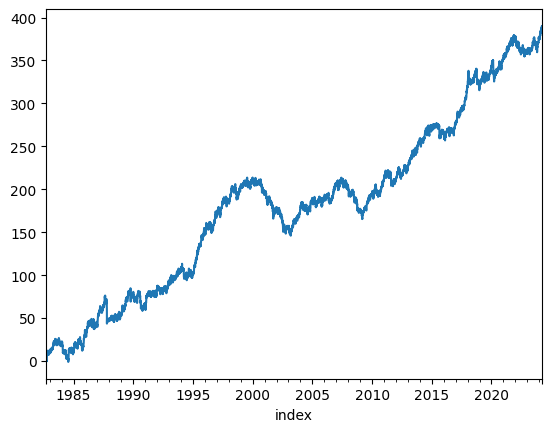

In [ ]:
import syscore.pandas.strategy_functions

account.sharpe()  ## get the Sharpe Ratio (annualised), and any other statistic which is in the stats list
account.curve().plot()  ## plot the cumulative account curve (equivalent to account.cumsum().plot() inicidentally)
account.percent  ## gives a % curve
syscore.pandas.strategy_functions.drawdown().plot()  ## see the drawdowns as a percentage
account.weekly  ## weekly returns (also daily [default], monthly, annual)
account.gross.ann_mean()  ## annual mean for gross returns, also costs (there are none in this simple example)
